# **1. Project Overview**

## **Airbnb Price Band Classification**

### **Research Questions**
1. **RQ1**: Can machine learning models accurately classify Airbnb listings into price bands?
2. **RQ2**: Which attributes drive price classification the most?
3. **RQ3**: How do key features influence the probability of a listing being in a high price band?

### **Dataset**
- **Source**: Airbnb listings data (listings.csv)
- **Target**: Price band classification (Low, Mid, High)
- **Features**: Room type, neighbourhood, reviews, location, minimum stay, etc.

### **Models & Techniques**
- **Baseline Models**: Random Forest, SVM (RBF), KNN
- **Optimization**: Bayesian Search with scikit-optimize
- **Class Balancing**: SMOTE (Synthetic Minority Over-sampling Technique)
- **Validation**: Stratified K-Fold Cross-Validation
- **Interpretability**: Feature Importance (Gini), Partial Dependence Plots

# **2. Import Libraries**

## **2.1 Import Required Packages**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.preprocessing import (
    OneHotEncoder,
    label_binarize,
    StandardScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import PartialDependenceDisplay

# Install scikit-optimize if not already installed
try:
    from skopt import BayesSearchCV
except ImportError:
    print("Installing scikit-optimize...")
    import subprocess
    subprocess.check_call(
        ["pip", "install", "-q", "scikit-optimize"]
    )
    print("Installation complete.")
    from skopt import BayesSearchCV # Import after installation

from skopt.space import Real, Categorical, Integer

from imblearn.over_sampling import SMOTE

print("All libraries imported successfully.")

All libraries imported successfully.


# **3. Load Dataset**

## **3.1 Read CSV and Inspect Shape**

In [ ]:
df = pd.read_csv("listings.csv", low_memory=False)

print(f"Raw dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
print(df.head())


Raw dataset shape: (10168, 18)
Rows: 10168, Columns: 18

First 5 rows:
      id                                               name  host_id  \
0  27886  Romantic, stylish B&B houseboat in canal district    97647   
1  28871                            Comfortable double room   124245   
2  29051                   Comfortable single / double room   124245   
3  44391    Quiet 2-bedroom Amsterdam city centre apartment   194779   
4  47061                   Charming apartment in old centre   211696   

  host_name  neighbourhood_group           neighbourhood  latitude  longitude  \
0      Flip                  NaN            Centrum-West  52.38761    4.89188   
1     Edwin                  NaN            Centrum-West  52.36775    4.89092   
2     Edwin                  NaN            Centrum-Oost  52.36584    4.89111   
3       Jan                  NaN            Centrum-Oost  52.37168    4.91471   
4      Ivar                  NaN  De Baarsjes - Oud-West  52.36786    4.87458   

         

## **3.2 Inspect Dataset Structure**

In [ ]:
print("Dataset Info:")
df.info()
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10168 entries, 0 to 10167
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10168 non-null  int64  
 1   name                            10168 non-null  object 
 2   host_id                         10168 non-null  int64  
 3   host_name                       10164 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   10168 non-null  object 
 6   latitude                        10168 non-null  float64
 7   longitude                       10168 non-null  float64
 8   room_type                       10168 non-null  object 
 9   price                           6321 non-null   float64
 10  minimum_nights                  10168 non-null  int64  
 11  number_of_reviews               10168 non-null  int64  
 12  last_review       

# **4. Data Preprocessing**

## **4.1 Remove Unavailable Listings**

In [ ]:
# Unavailable listings have missing prices (delisted properties)
rows_before = len(df)
missing_prices = df['price'].isna().sum()

df_clean = df.dropna(subset=['price']).copy()

rows_after = len(df_clean)
removed = rows_before - rows_after

print(f"Rows before removing unavailable: {rows_before}")
print(f"Rows with missing price: {missing_prices}")
print(f"Rows after removal: {rows_after}")
print(f"Total removed: {removed}")


Rows before removing unavailable: 10168
Rows with missing price: 3847
Rows after removal: 6321
Total removed: 3847


## **4.2 Remove Non-Predictive Columns**

In [ ]:
# These columns are not useful for price prediction
# or would cause data leakage issues
cols_to_drop = [
    "id",
    "name",
    "host_id",
    "host_name",
    "neighbourhood_group",
    "license",
]

# Only drop columns that exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {df_clean.shape[1]}")
print(f"\nDataset shape after column removal: {df_clean.shape}")


Dropped columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'license']
Remaining columns: 12

Dataset shape after column removal: (6321, 12)


## **4.3 Handle Remaining Missing Values**

In [ ]:
# Fill reviews_per_month with median
if "reviews_per_month" in df_clean.columns:
    median_reviews = df_clean["reviews_per_month"].median()
    df_clean["reviews_per_month"] = (
        df_clean["reviews_per_month"].fillna(median_reviews)
    )

# Fill last_review with placeholder (indicates no reviews)
if "last_review" in df_clean.columns:
    df_clean["last_review"] = df_clean["last_review"].fillna("No Review")

# Drop rows with missing essential categorical columns
df_clean = df_clean.dropna(subset=["room_type", "neighbourhood"])

print("Missing values after handling:")
print(df_clean.isna().sum())
print(f"\nDataset shape: {df_clean.shape}")


Missing values after handling:
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
dtype: int64

Dataset shape: (6321, 12)


## **4.4 Remove Price Outliers (Top 5%)**

In [ ]:
# Calculate 95th percentile
price_p95 = df_clean["price"].quantile(0.95)

rows_before_outlier = len(df_clean)
df_clean = df_clean[df_clean["price"] <= price_p95]
rows_after_outlier = len(df_clean)

removed_outliers = rows_before_outlier - rows_after_outlier

print(f"95th percentile price: ${price_p95:.2f}")
print(f"Rows before outlier removal: {rows_before_outlier}")
print(f"Rows after outlier removal: {rows_after_outlier}")
print(f"Outliers removed: {removed_outliers}")


95th percentile price: $550.00
Rows before outlier removal: 6321
Rows after outlier removal: 6006
Outliers removed: 315


## **4.5 Create Price Band Categories**

In [ ]:
# Use quantile-based binning to create price bands
# This ensures balanced classes
q1 = df_clean["price"].quantile(0.33)
q2 = df_clean["price"].quantile(0.66)

print("Price thresholds:")
print(f"  Low:  <= ${q1:.2f}")
print(f"  Mid:  ${q1:.2f} - ${q2:.2f}")
print(f"  High: > ${q2:.2f}")


def price_to_band(price):
    '''Convert price to band category.'''
    if price <= q1:
        return "Low"
    elif price <= q2:
        return "Mid"
    else:
        return "High"


df_clean["price_band"] = df_clean["price"].apply(price_to_band)

print("\nPrice band distribution:")
print(df_clean["price_band"].value_counts().sort_index())
print("\nProportion:")
print(df_clean["price_band"].value_counts(normalize=True).sort_index())


Price thresholds:
  Low:  <= $178.00
  Mid:  $178.00 - $261.00
  High: > $261.00

Price band distribution:
price_band
High    2036
Low     1985
Mid     1985
Name: count, dtype: int64

Proportion:
price_band
High    0.338994
Low     0.330503
Mid     0.330503
Name: proportion, dtype: float64


## **4.6 Verify Cleaned Dataset**

In [ ]:
print("Final cleaned dataset structure:")
df_clean.info()

print(f"\nFinal shape: {df_clean.shape}")
print(f"\nMissing values:")
print(df_clean.isna().sum())

print(f"\nFirst few rows:")
print(df_clean.head())


Final cleaned dataset structure:
<class 'pandas.core.frame.DataFrame'>
Index: 6006 entries, 0 to 10167
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood                   6006 non-null   object 
 1   latitude                        6006 non-null   float64
 2   longitude                       6006 non-null   float64
 3   room_type                       6006 non-null   object 
 4   price                           6006 non-null   float64
 5   minimum_nights                  6006 non-null   int64  
 6   number_of_reviews               6006 non-null   int64  
 7   last_review                     6006 non-null   object 
 8   reviews_per_month               6006 non-null   float64
 9   calculated_host_listings_count  6006 non-null   int64  
 10  availability_365                6006 non-null   int64  
 11  number_of_reviews_ltm           6006 non-null   int64  
 12  price

# **5. Exploratory Data Analysis (EDA)**

## **5.1 Price Distribution (Histogram)**

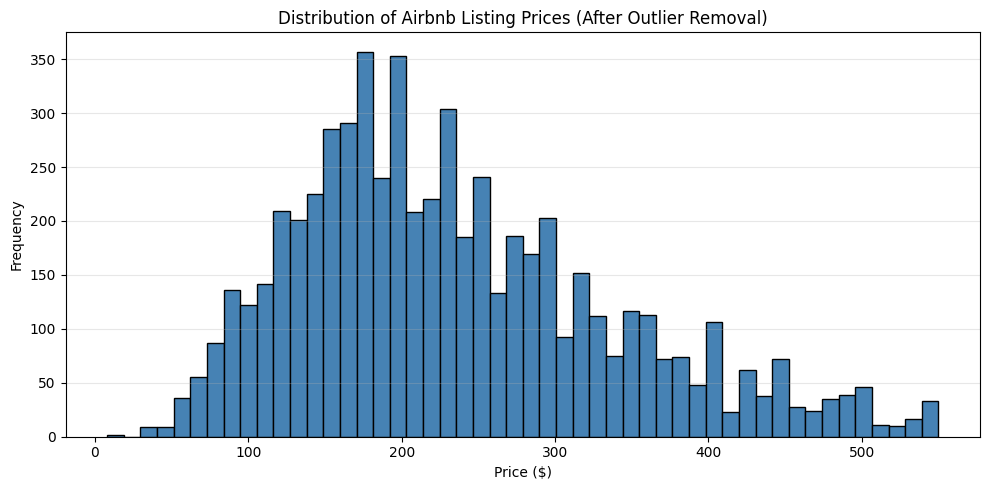

Price statistics:
count    6006.000000
mean      234.764236
std       104.231151
min         8.000000
25%       159.000000
50%       215.000000
75%       298.000000
max       550.000000
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean["price"], bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Airbnb Listing Prices (After Outlier Removal)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Price statistics:")
print(df_clean["price"].describe())


## **5.2 Boxplot of Prices (After Outlier Removal)**

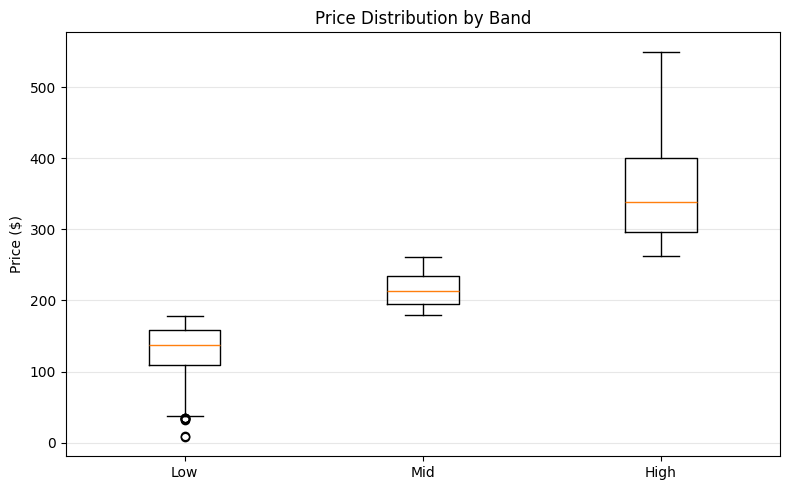

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [df_clean[df_clean["price_band"] == band]["price"]
     for band in ["Low", "Mid", "High"]],
    labels=["Low", "Mid", "High"]
)
plt.ylabel("Price ($)")
plt.title("Price Distribution by Band")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## **5.3 Median Price by Room Type**

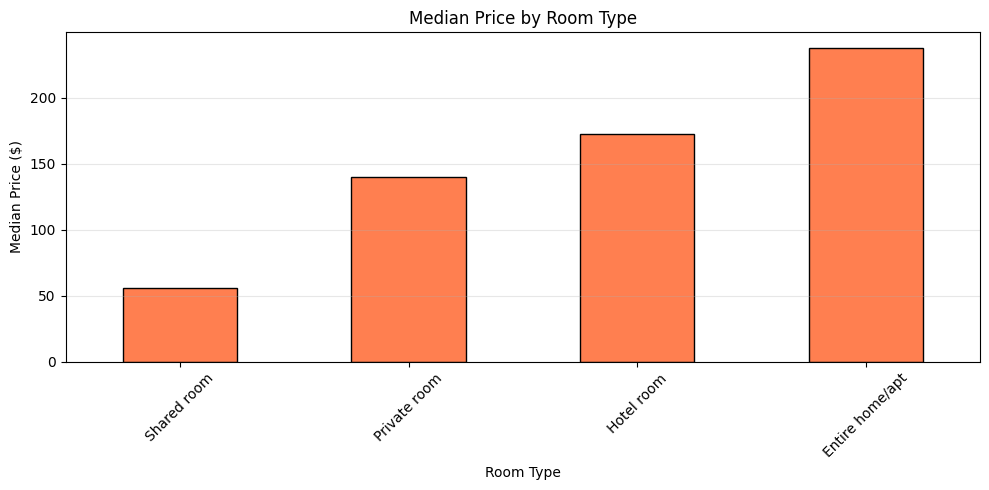

Median price by room type:
room_type
Shared room         56.0
Private room       140.0
Hotel room         172.0
Entire home/apt    237.5
Name: price, dtype: float64


In [ ]:
median_by_room = df_clean.groupby("room_type")["price"].median().sort_values()

plt.figure(figsize=(10, 5))
median_by_room.plot(kind="bar", color="coral", edgecolor="black")
plt.xlabel("Room Type")
plt.ylabel("Median Price ($)")
plt.title("Median Price by Room Type")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Median price by room type:")
print(median_by_room)


## **5.4 Price Band Class Balance**

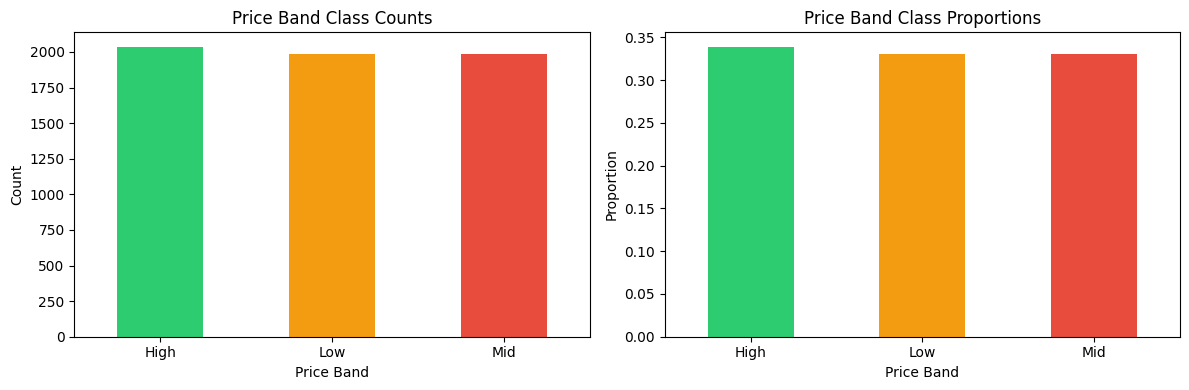

Class distribution:
price_band
High    2036
Low     1985
Mid     1985
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df_clean["price_band"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)
axes[0].set_title("Price Band Class Counts")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Price Band")
axes[0].tick_params(axis="x", rotation=0)

# Proportion plot
df_clean["price_band"].value_counts(normalize=True).plot(
    kind="bar",
    ax=axes[1],
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)
axes[1].set_title("Price Band Class Proportions")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Price Band")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Class distribution:")
print(df_clean["price_band"].value_counts())


## **5.5 Correlation Heatmap (Price Excluded)**

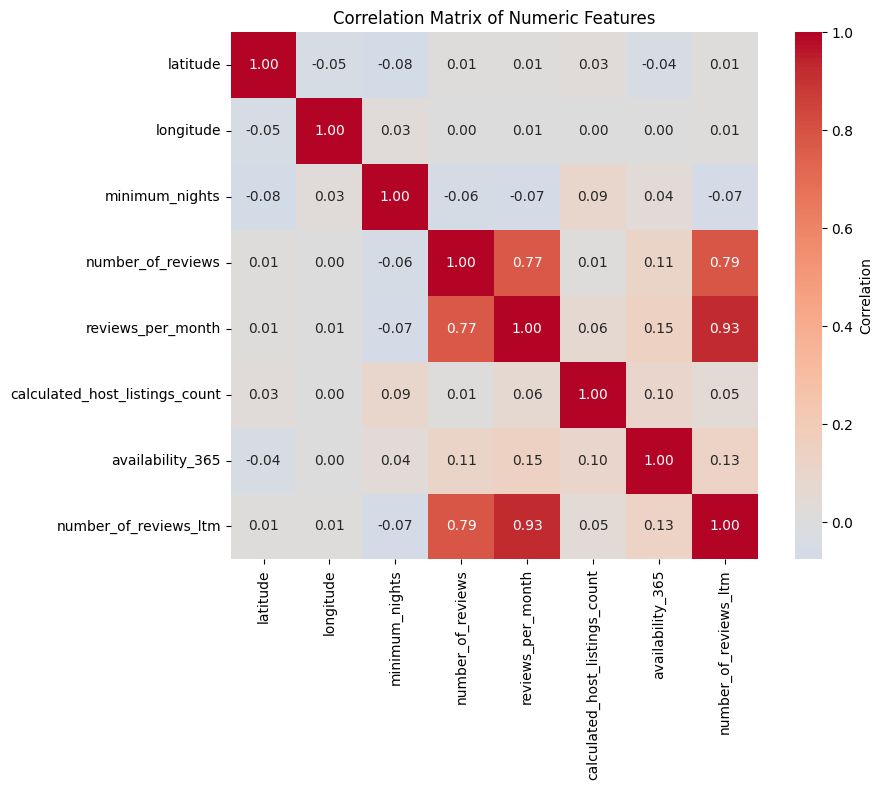

Features in correlation matrix: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']


In [ ]:
# Select numeric columns only (excluding price_band and price)
numeric_cols = (
    df_clean.select_dtypes(include=[np.number]).columns.tolist()
)
if "price" in numeric_cols:
    numeric_cols.remove("price")

# Calculate correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

print(f"Features in correlation matrix: {numeric_cols}")


# **6. Feature Engineering & Data Splitting**

## **6.1 Prepare Feature Matrix (Drop Price to Prevent Data Leakage)**

In [ ]:
# IMPORTANT: We drop the 'price' column to prevent data leakage.
# The model must learn to classify price bands from OTHER attributes,
# not by simply memorizing the exact price values.
# The price_band target was derived from price, but the price column itself
# should NOT appear in X (features).

df_model = df_clean.copy()
target_col = "price_band"

# Extract target variable
y = df_model[target_col].astype("category")

# Define columns to exclude from features
cols_to_exclude = [target_col, "price", "last_review"]
X_raw = df_model.drop(
    columns=[c for c in cols_to_exclude if c in df_model.columns]
)

print(f"Features before encoding: {X_raw.shape[1]}")
print(f"Features: {list(X_raw.columns)}")

# One-Hot Encoding (get_dummies for simplicity)
X = pd.get_dummies(X_raw, dummy_na=False)
print(f"Features after one-hot encoding: {X.shape[1]}")

# Fill any remaining NaN values with median
X = X.fillna(X.median(numeric_only=True))

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"\nFinal feature matrix shape: {X_scaled.shape}")
print(f"'price' in features: {'price' in X_scaled.columns}")
print(f"\nTarget variable distribution:")
print(y.value_counts().sort_index())

# Verify class order for later use
CLASS_ORDER = sorted(list(y.cat.categories))
print(f"\nClass order: {CLASS_ORDER}")


Features before encoding: 10
Features: ['neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']
Features after one-hot encoding: 34

Final feature matrix shape: (6006, 34)
'price' in features: False

Target variable distribution:
price_band
High    2036
Low     1985
Mid     1985
Name: count, dtype: int64

Class order: ['High', 'Low', 'Mid']


## **6.2 Train-Test Split (80/20 Stratified)**

In [ ]:
# Use stratified split to maintain class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())

print(f"\nTest set class distribution:")
print(y_test.value_counts().sort_index())


Training set size: (4804, 34)
Test set size: (1202, 34)

Training set class distribution:
price_band
High    1628
Low     1588
Mid     1588
Name: count, dtype: int64

Test set class distribution:
price_band
High    408
Low     397
Mid     397
Name: count, dtype: int64


# **7. Define Baseline Models**

## **7.1 Initialise Random Forest, SVM, and KNN**

In [ ]:
import time

# Define baseline models with standard hyperparameters
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        C=2.0,
        gamma="scale",
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance"
    ),
}

# Color schemes for confusion matrices
CMAPS_CM = {
    "Random Forest": "Greens",
    "SVM (RBF)": "Oranges",
    "KNN": "Reds",
}

# Color schemes for ROC curves
ROC_COLORS = {
    "Random Forest": "#27ae60",
    "SVM (RBF)": "#e67e22",
    "KNN": "#c0392b",
}

print("Baseline models defined:")
for name, model in models.items():
    print(f"  - {name}")


Baseline models defined:
  - Random Forest
  - SVM (RBF)
  - KNN


# **8. Baseline Model Evaluation**

## **8.1 Train and Evaluate Baseline Models**

Training and evaluating baseline models...
Classes for ROC: [np.str_('High'), np.str_('Low'), np.str_('Mid')]

Random Forest
----------------------------------------------------------------------
Accuracy: 0.5316
Weighted F1-Score: 0.5323

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.59      0.56       408
         Low       0.67      0.60      0.63       397
         Mid       0.41      0.40      0.40       397

    accuracy                           0.53      1202
   macro avg       0.54      0.53      0.53      1202
weighted avg       0.54      0.53      0.53      1202



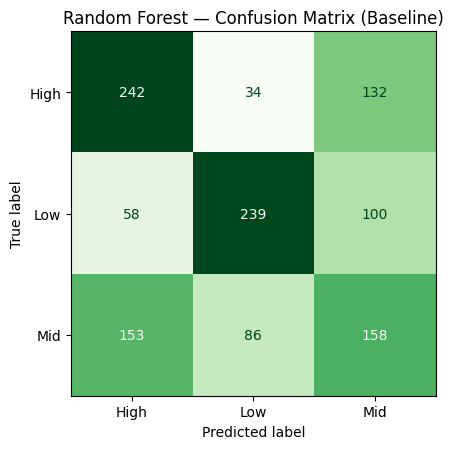


SVM (RBF)
----------------------------------------------------------------------
Accuracy: 0.5374
Weighted F1-Score: 0.5356

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.65      0.58       408
         Low       0.66      0.57      0.61       397
         Mid       0.43      0.39      0.41       397

    accuracy                           0.54      1202
   macro avg       0.54      0.54      0.54      1202
weighted avg       0.54      0.54      0.54      1202



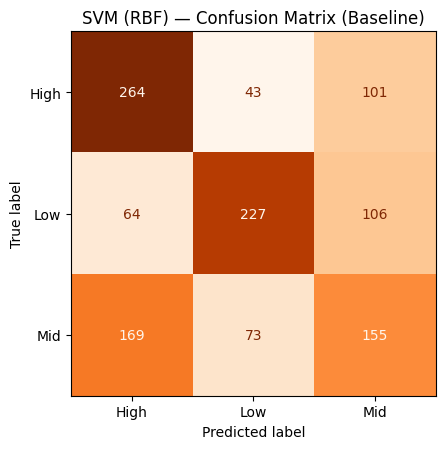


KNN
----------------------------------------------------------------------
Accuracy: 0.5441
Weighted F1-Score: 0.5443

Classification Report:
              precision    recall  f1-score   support

        High       0.54      0.59      0.56       408
         Low       0.67      0.62      0.64       397
         Mid       0.43      0.42      0.43       397

    accuracy                           0.54      1202
   macro avg       0.55      0.54      0.54      1202
weighted avg       0.55      0.54      0.54      1202



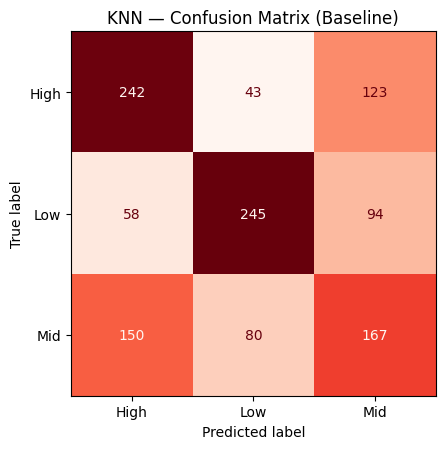


BASELINE MODEL METRICS SUMMARY
               accuracy  f1_weighted  roc_auc_macro  train_time_s  test_time_s
model                                                                         
KNN              0.5441       0.5443         0.7172        0.0059       0.0482
SVM (RBF)        0.5374       0.5356         0.7184       20.2701       0.3045
Random Forest    0.5316       0.5323         0.7273        4.3271       0.2155


In [ ]:
# Prepare for ROC curve calculation
classes_for_roc = np.array(CLASS_ORDER)
y_test_bin = label_binarize(y_test, classes=classes_for_roc)
n_classes = len(CLASS_ORDER)

metrics_rows = []
roc_data_storage = []

print("Training and evaluating baseline models...")
print(f"Classes for ROC: {list(classes_for_roc)}")
print("=" * 70)

for name, clf in models.items():
    print(f"\n{name}")
    print("-" * 70)

    # Train
    t0 = time.perf_counter()
    clf.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # Predict
    t1 = time.perf_counter()
    y_pred = clf.predict(X_test)
    test_time = time.perf_counter() - t1

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")

    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1-Score: {f1w:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_ORDER
    )
    fig_cm, ax_cm = plt.subplots(figsize=(5.8, 4.6))
    disp.plot(
        values_format="d",
        cmap=CMAPS_CM.get(name, "Blues"),
        colorbar=False,
        ax=ax_cm
    )
    ax_cm.set_title(f"{name} — Confusion Matrix (Baseline)")
    plt.tight_layout()
    plt.show()

    # ROC AUC
    roc_auc_macro = np.nan
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)
        try:
            roc_auc_macro = roc_auc_score(
                y_test_bin,
                y_score,
                average="macro",
                multi_class="ovr"
            )
        except ValueError as e:
            print(f"ROC AUC calculation note: {e}")

        roc_data_storage.append({
            "name": name,
            "y_score": y_score,
            "color": ROC_COLORS.get(name, None)
        })

    # Store metrics
    metrics_rows.append({
        "model": name,
        "accuracy": acc,
        "f1_weighted": f1w,
        "roc_auc_macro": roc_auc_macro,
        "train_time_s": train_time,
        "test_time_s": test_time
    })

# Summary table
metrics_df = pd.DataFrame(metrics_rows).sort_values(
    by="accuracy",
    ascending=False
)

print("\n" + "=" * 70)
print("BASELINE MODEL METRICS SUMMARY")
print("=" * 70)
print(metrics_df.set_index("model").round(4).to_string())


## **8.2 Baseline ROC Curves (One per Class)**

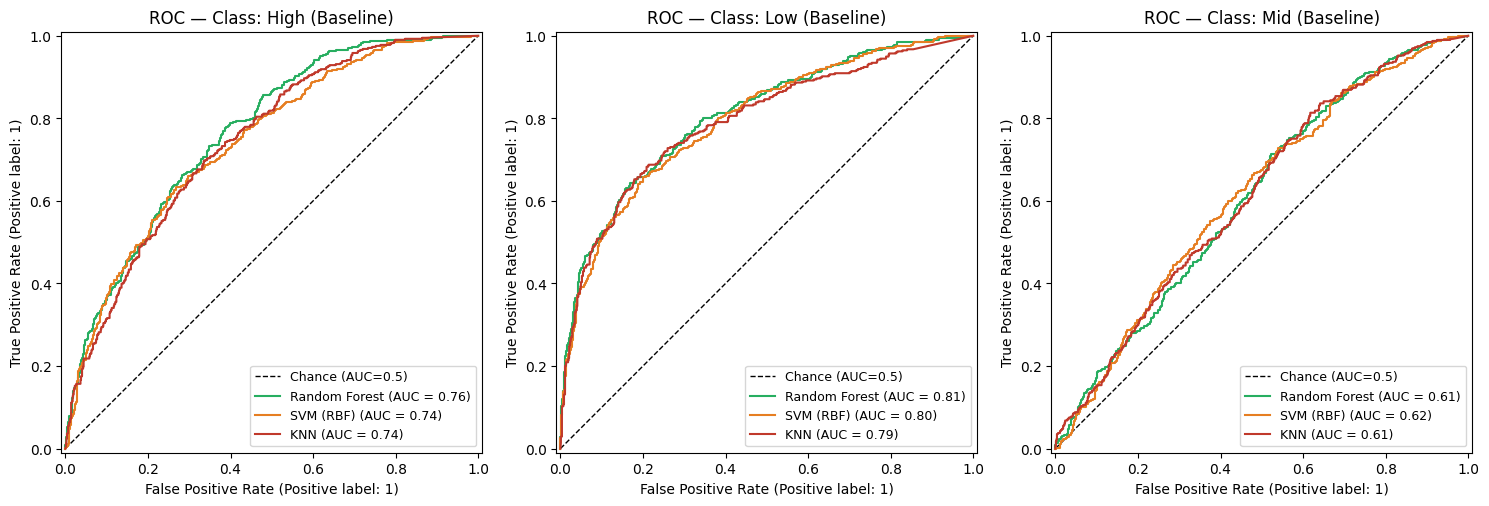

In [ ]:
# Combined ROC Plot (one subplot per class)
fig_roc, axes_roc = plt.subplots(1, n_classes, figsize=(5*n_classes, 5))
if n_classes == 1:
    axes_roc = [axes_roc]

for class_idx in range(n_classes):
    ax = axes_roc[class_idx]

    # Diagonal reference line
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance (AUC=0.5)")

    # Plot ROC curves for each model
    for item in roc_data_storage:
        RocCurveDisplay.from_predictions(
            y_test_bin[:, class_idx],
            item["y_score"][:, class_idx],
            name=item["name"],
            color=item["color"],
            ax=ax
        )

    ax.set_title(f"ROC — Class: {CLASS_ORDER[class_idx]} (Baseline)")
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


## **8.3 Baseline Metrics Heatmap**

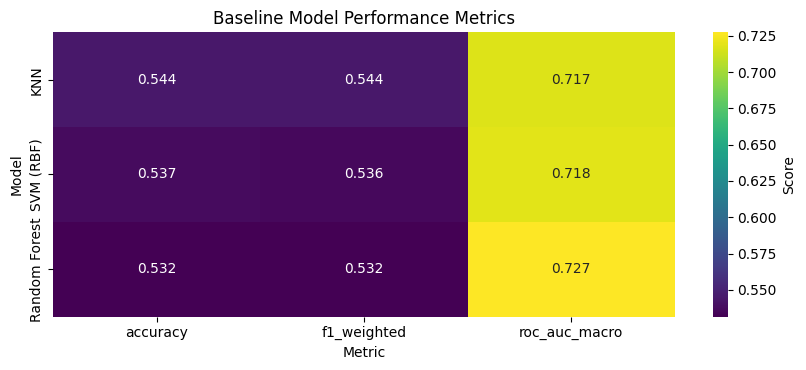

In [ ]:
plt.figure(figsize=(8.5, 3.8))
sns.heatmap(
    metrics_df.set_index("model")[
        ["accuracy", "f1_weighted", "roc_auc_macro"]
    ],
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={"label": "Score"}
)
plt.title("Baseline Model Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


# **9. Hyperparameter Tuning with Bayesian Optimisation**

## **9.1 Install scikit-optimize**

In [ ]:
# scikit-optimize is used for Bayesian hyperparameter search
# Installation check
try:
    from skopt import BayesSearchCV
    print("scikit-optimize is already installed.")
except ImportError:
    print("Installing scikit-optimize...")
    import subprocess
    subprocess.check_call(
        ["pip", "install", "-q", "scikit-optimize"]
    )
    print("Installation complete.")


scikit-optimize is already installed.


## **9.2 Apply SMOTE for Class Balancing**

In [ ]:
# SMOTE: Synthetic Minority Over-sampling Technique
# Creates synthetic samples for minority classes to balance the training set
print("Applying SMOTE to balance training classes...")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE:")
print(f"  {dict(y_train.value_counts())}")

print(f"\nAfter SMOTE:")
print(f"  {dict(pd.Series(y_train_balanced).value_counts())}")

print(f"\nBalanced training set shape: {X_train_balanced.shape}")
print(f"Original training set shape: {X_train.shape}")


Applying SMOTE to balance training classes...

Before SMOTE:
  {'High': np.int64(1628), 'Low': np.int64(1588), 'Mid': np.int64(1588)}

After SMOTE:
  {'High': np.int64(1628), 'Low': np.int64(1628), 'Mid': np.int64(1628)}

Balanced training set shape: (4884, 34)
Original training set shape: (4804, 34)


## **9.3 Define Bayesian Search Spaces**

In [ ]:
# Define hyperparameter search spaces for each model
models_config = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "search_space": {
            "n_estimators": Integer(100, 500),
            "max_depth": Integer(5, 50),
            "min_samples_split": Integer(2, 20),
            "min_samples_leaf": Integer(1, 10),
            "criterion": Categorical(["gini", "entropy"])
        },
        "color_cm": "Greens",
        "color_roc": "#27ae60"
    },
    "SVM (RBF)": {
        "model": SVC(probability=True, random_state=42),
        "search_space": {
            "C": Real(0.1, 100, prior="log-uniform"),
            "gamma": Categorical(["scale", "auto"]),
            "kernel": Categorical(["rbf"])
        },
        "color_cm": "Oranges",
        "color_roc": "#e67e22"
    },
    "KNN": {
        "model": KNeighborsClassifier(n_jobs=-1),
        "search_space": {
            "n_neighbors": Integer(3, 30),
            "weights": Categorical(["uniform", "distance"]),
            "p": Integer(1, 2)
        },
        "color_cm": "Reds",
        "color_roc": "#c0392b"
    }
}

print("Search spaces defined for Bayesian Optimization:")
for name, config in models_config.items():
    print(f"\n{name}:")
    for param, space in config["search_space"].items():
        print(f"  {param}: {space}")


Search spaces defined for Bayesian Optimization:

Random Forest:
  n_estimators: Integer(low=100, high=500, prior='uniform', transform='identity')
  max_depth: Integer(low=5, high=50, prior='uniform', transform='identity')
  min_samples_split: Integer(low=2, high=20, prior='uniform', transform='identity')
  min_samples_leaf: Integer(low=1, high=10, prior='uniform', transform='identity')
  criterion: Categorical(categories=('gini', 'entropy'), prior=None)

SVM (RBF):
  C: Real(low=0.1, high=100, prior='log-uniform', transform='identity')
  gamma: Categorical(categories=('scale', 'auto'), prior=None)
  kernel: Categorical(categories=('rbf',), prior=None)

KNN:
  n_neighbors: Integer(low=3, high=30, prior='uniform', transform='identity')
  weights: Categorical(categories=('uniform', 'distance'), prior=None)
  p: Integer(low=1, high=2, prior='uniform', transform='identity')


## **9.4 Run Bayesian Optimisation (Tuned + SMOTE)**


BAYESIAN HYPERPARAMETER OPTIMIZATION (20 iterations)

Optimizing: Random Forest
----------------------------------------------------------------------
Best parameters: OrderedDict({'criterion': 'gini', 'max_depth': 41, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 498})
Best CV accuracy: 0.5551

Test set performance:
  Accuracy: 0.5266
  Weighted F1: 0.5267

Classification Report:
              precision    recall  f1-score   support

        High       0.54      0.58      0.56       408
         Low       0.65      0.61      0.63       397
         Mid       0.39      0.39      0.39       397

    accuracy                           0.53      1202
   macro avg       0.53      0.53      0.53      1202
weighted avg       0.53      0.53      0.53      1202



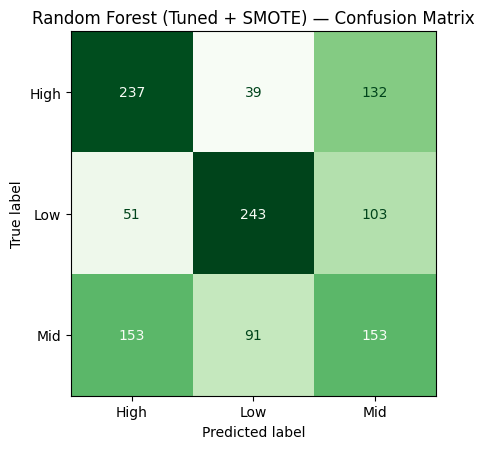


Optimizing: SVM (RBF)
----------------------------------------------------------------------
Best parameters: OrderedDict({'C': 27.364528220782454, 'gamma': 'scale', 'kernel': 'rbf'})
Best CV accuracy: 0.5444

Test set performance:
  Accuracy: 0.5300
  Weighted F1: 0.5341

Classification Report:
              precision    recall  f1-score   support

        High       0.54      0.58      0.56       408
         Low       0.68      0.55      0.61       397
         Mid       0.41      0.46      0.44       397

    accuracy                           0.53      1202
   macro avg       0.54      0.53      0.53      1202
weighted avg       0.54      0.53      0.53      1202



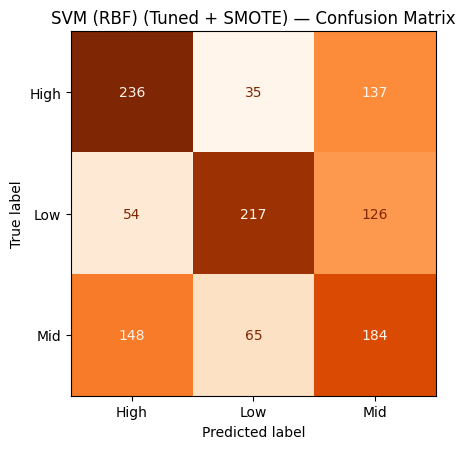


Optimizing: KNN
----------------------------------------------------------------------
Best parameters: OrderedDict({'n_neighbors': 23, 'p': 2, 'weights': 'distance'})
Best CV accuracy: 0.5438

Test set performance:
  Accuracy: 0.5441
  Weighted F1: 0.5444

Classification Report:
              precision    recall  f1-score   support

        High       0.55      0.62      0.58       408
         Low       0.67      0.60      0.63       397
         Mid       0.42      0.41      0.42       397

    accuracy                           0.54      1202
   macro avg       0.55      0.54      0.54      1202
weighted avg       0.55      0.54      0.54      1202



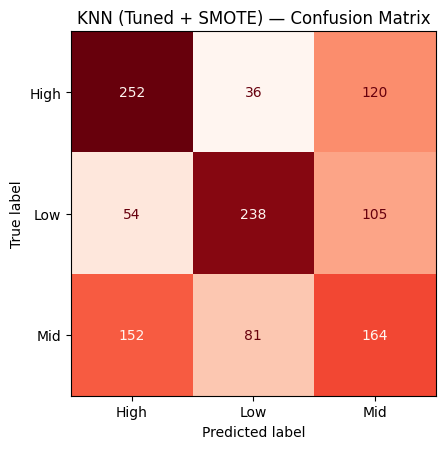


TUNED + SMOTE MODEL METRICS SUMMARY
               accuracy  f1_weighted  roc_auc_macro  train_time_s
model                                                            
KNN              0.5441       0.5444         0.7277       16.5246
SVM (RBF)        0.5300       0.5341         0.7131      260.8019
Random Forest    0.5266       0.5267         0.7252      120.5592


In [ ]:
# Run Bayesian Search on SMOTE-balanced data
tuned_models = {}
tuned_metrics_rows = []

print("\n" + "=" * 70)
print("BAYESIAN HYPERPARAMETER OPTIMIZATION (20 iterations)")
print("=" * 70)

for name, config in models_config.items():
    print(f"\nOptimizing: {name}")
    print("-" * 70)

    t0 = time.perf_counter()

    # Bayesian Search
    opt = BayesSearchCV(
        estimator=config["model"],
        search_spaces=config["search_space"],
        n_iter=20,
        cv=3,
        n_jobs=-1,
        random_state=42,
        scoring="accuracy",
        verbose=0
    )

    opt.fit(X_train_balanced, y_train_balanced)
    train_time = time.perf_counter() - t0

    best_model = opt.best_estimator_
    tuned_models[name] = best_model

    print(f"Best parameters: {opt.best_params_}")
    print(f"Best CV accuracy: {opt.best_score_:.4f}")

    # Evaluate on test set
    t1 = time.perf_counter()
    y_pred = best_model.predict(X_test)
    test_time = time.perf_counter() - t1

    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")

    print(f"\nTest set performance:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Weighted F1: {f1w:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_ORDER
    )
    fig_cm, ax_cm = plt.subplots(figsize=(5.8, 4.6))
    disp.plot(
        values_format="d",
        cmap=config["color_cm"],
        colorbar=False,
        ax=ax_cm
    )
    ax_cm.set_title(f"{name} (Tuned + SMOTE) — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ROC AUC
    roc_auc_macro = np.nan
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test)
        try:
            roc_auc_macro = roc_auc_score(
                y_test_bin,
                y_score,
                average="macro",
                multi_class="ovr"
            )
        except ValueError as e:
            print(f"ROC AUC calculation note: {e}")

    # Store metrics
    tuned_metrics_rows.append({
        "model": name,
        "accuracy": acc,
        "f1_weighted": f1w,
        "roc_auc_macro": roc_auc_macro,
        "train_time_s": train_time,
        "test_time_s": test_time,
        "best_params": str(opt.best_params_)
    })

# Summary
tuned_metrics_df = pd.DataFrame(tuned_metrics_rows).sort_values(
    by="accuracy",
    ascending=False
)

print("\n" + "=" * 70)
print("TUNED + SMOTE MODEL METRICS SUMMARY")
print("=" * 70)
print(tuned_metrics_df.set_index("model")[
    ["accuracy", "f1_weighted", "roc_auc_macro", "train_time_s"]
].round(4).to_string())


## **9.5 Combined ROC Curves (Tuned + SMOTE)**

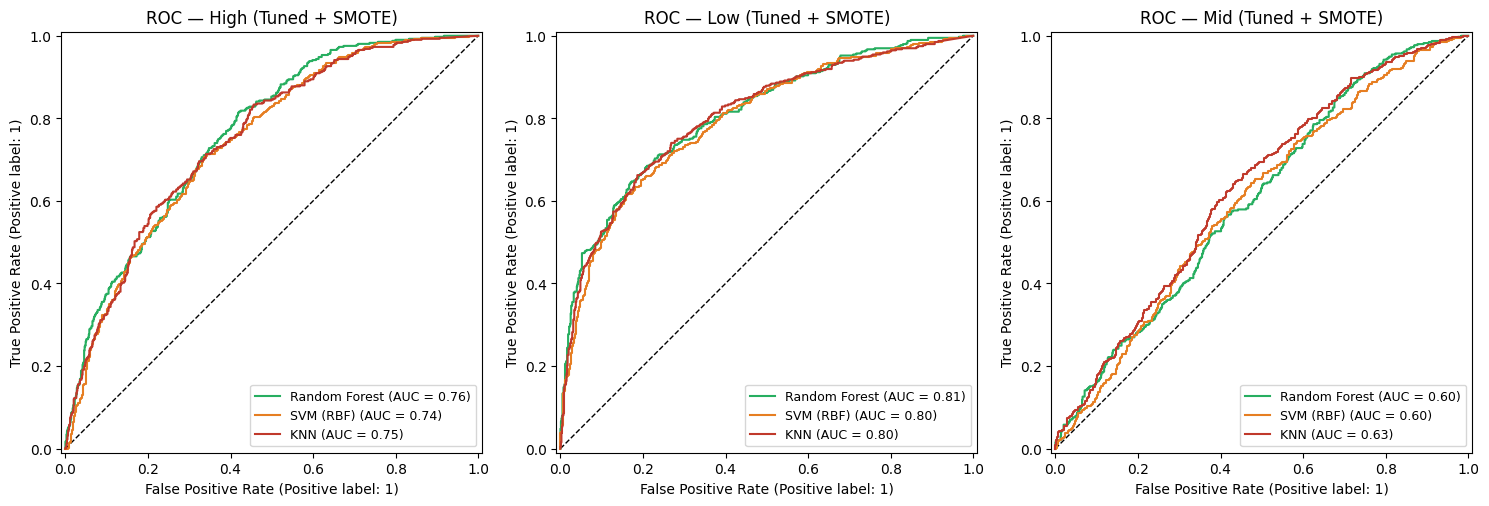

In [ ]:
# Generate ROC curves for all tuned models
fig_roc, axes_roc = plt.subplots(1, n_classes, figsize=(5*n_classes, 5))
if n_classes == 1:
    axes_roc = [axes_roc]

for class_idx in range(n_classes):
    ax = axes_roc[class_idx]

    # Diagonal reference
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)

    # Plot ROC for each tuned model
    for name, model in tuned_models.items():
        y_score = model.predict_proba(X_test)
        RocCurveDisplay.from_predictions(
            y_test_bin[:, class_idx],
            y_score[:, class_idx],
            name=name,
            color=models_config[name]["color_roc"],
            ax=ax
        )

    ax.set_title(f"ROC — {CLASS_ORDER[class_idx]} (Tuned + SMOTE)")
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


## **9.6 Tuned Model Metrics Summary and Heatmap**

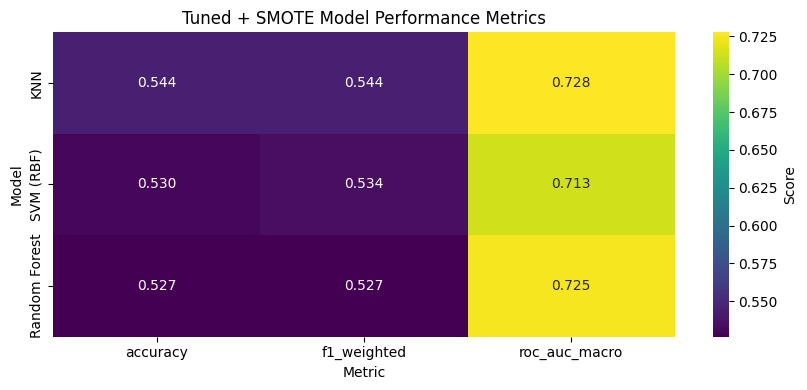


Tuned models are ready for cross-validation and analysis.


In [ ]:
# Display metrics heatmap
plt.figure(figsize=(8.5, 4.0))
sns.heatmap(
    tuned_metrics_df.set_index("model")[
        ["accuracy", "f1_weighted", "roc_auc_macro"]
    ],
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={"label": "Score"}
)
plt.title("Tuned + SMOTE Model Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

print("\nTuned models are ready for cross-validation and analysis.")


# **10. Cross-Validation**

## **10.1 5-Fold Stratified Cross-Validation**

5-FOLD STRATIFIED CROSS-VALIDATION
(Using SMOTE-balanced training data)

Cross-validating: Random Forest
  Mean: 0.5598 ± 0.0158
  Min:  0.5455
  Max:  0.5896

Cross-validating: SVM (RBF)
  Mean: 0.5471 ± 0.0121
  Min:  0.5374
  Max:  0.5701

Cross-validating: KNN
  Mean: 0.5401 ± 0.0158
  Min:  0.5230
  Max:  0.5599



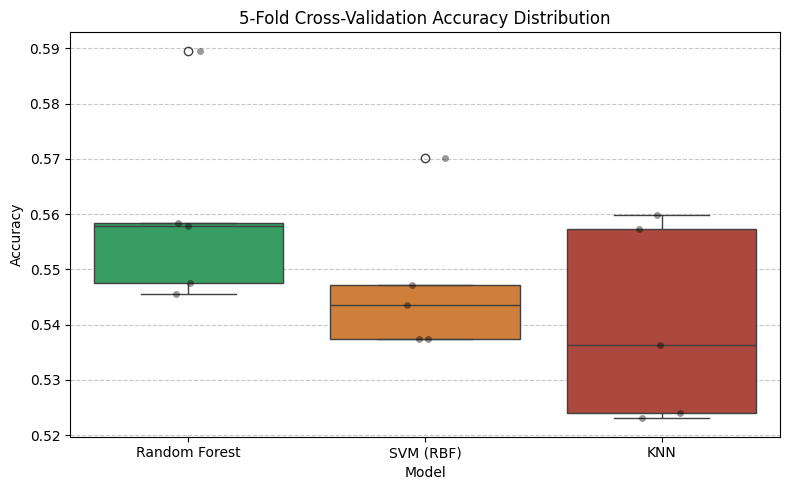

CROSS-VALIDATION SUMMARY
               mean_accuracy  std_dev  min_accuracy  max_accuracy
model                                                            
Random Forest         0.5598   0.0158        0.5455        0.5896
SVM (RBF)             0.5471   0.0121        0.5374        0.5701
KNN                   0.5401   0.0158        0.5230        0.5599


In [ ]:
# 5-Fold Stratified Cross-Validation on tuned models
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

cv_results = []
cv_summary = []

print("=" * 70)
print(f"{cv_folds}-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 70)
print("(Using SMOTE-balanced training data)")
print()

for name, model in tuned_models.items():
    print(f"Cross-validating: {name}")

    scores = cross_val_score(
        model,
        X_train_balanced,
        y_train_balanced,
        cv=skf,
        scoring="accuracy",
        n_jobs=-1
    )

    # Store individual fold results
    for fold_idx, score in enumerate(scores):
        cv_results.append({
            "model": name,
            "fold": fold_idx + 1,
            "accuracy": score
        })

    # Calculate summary statistics
    mean_score = np.mean(scores)
    std_score = np.std(scores)

    cv_summary.append({
        "model": name,
        "mean_accuracy": mean_score,
        "std_dev": std_score,
        "min_accuracy": np.min(scores),
        "max_accuracy": np.max(scores)
    })

    print(f"  Mean: {mean_score:.4f} ± {std_score:.4f}")
    print(f"  Min:  {np.min(scores):.4f}")
    print(f"  Max:  {np.max(scores):.4f}")
    print()

# Create dataframes
cv_df = pd.DataFrame(cv_results)
summary_df = pd.DataFrame(cv_summary).set_index("model")

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cv_df,
    x="model",
    y="accuracy",
    hue="model",
    palette=[
        models_config["Random Forest"]["color_roc"],
        models_config["SVM (RBF)"]["color_roc"],
        models_config["KNN"]["color_roc"]
    ],
    legend=False
)
sns.stripplot(
    data=cv_df,
    x="model",
    y="accuracy",
    color="black",
    alpha=0.4,
    jitter=True
)

plt.title(f"{cv_folds}-Fold Cross-Validation Accuracy Distribution")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)
print(summary_df.round(4).to_string())


# **11. Feature Importance Analysis (RQ2)**

## **11.1 Gini Importance from Tuned Random Forest**

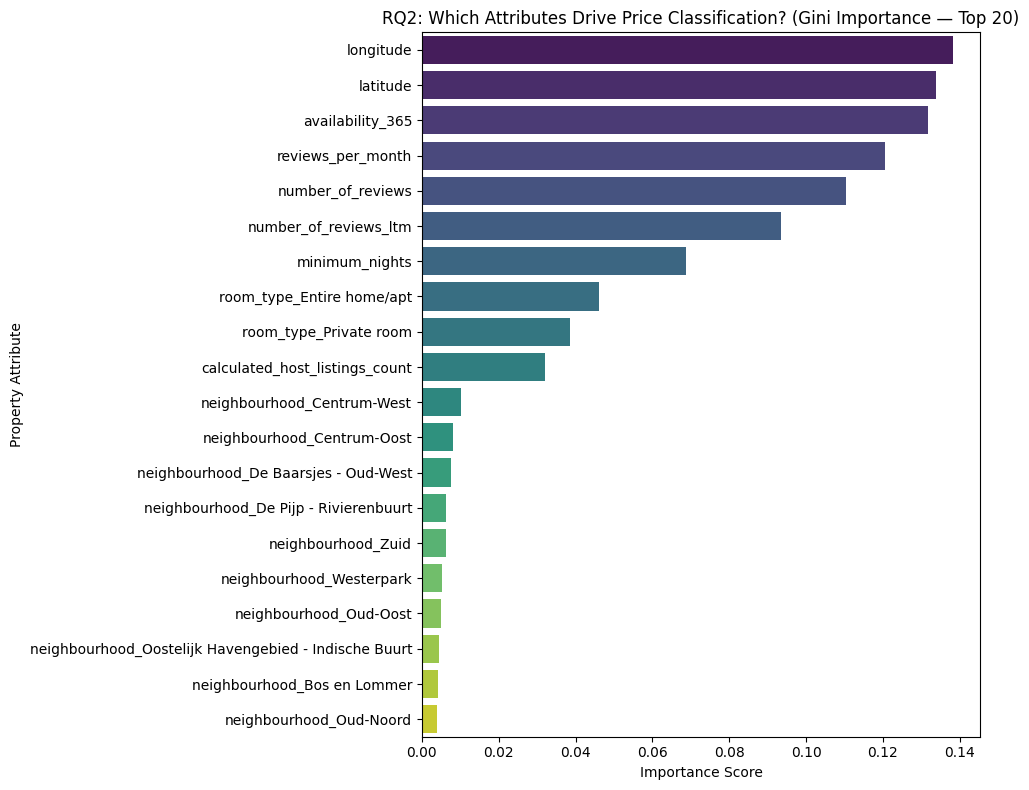

RQ2 ANALYSIS: TOP 10 FEATURES BY GINI IMPORTANCE
                       Feature  Gini Importance
                     longitude         0.138330
                      latitude         0.133878
              availability_365         0.131794
             reviews_per_month         0.120437
             number_of_reviews         0.110444
         number_of_reviews_ltm         0.093461
                minimum_nights         0.068677
     room_type_Entire home/apt         0.046075
        room_type_Private room         0.038501
calculated_host_listings_count         0.031979

Note: 'price' is NOT in the feature set.
These rankings show genuine property attributes driving price bands.


In [ ]:
# Extract feature importance from tuned Random Forest
rf_model = tuned_models["Random Forest"]
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_

# Create dataframe
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Gini Importance": importances
}).sort_values(by="Gini Importance", ascending=False)

# Visualization: Top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Gini Importance",
    y="Feature",
    data=feat_imp_df.head(20),
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title(
    "RQ2: Which Attributes Drive Price Classification? "
    "(Gini Importance — Top 20)"
)
plt.xlabel("Importance Score")
plt.ylabel("Property Attribute")
plt.tight_layout()
plt.show()

# Display top features
print("=" * 70)
print("RQ2 ANALYSIS: TOP 10 FEATURES BY GINI IMPORTANCE")
print("=" * 70)
print(feat_imp_df.head(10).to_string(index=False))
print()
print("Note: 'price' is NOT in the feature set.")
print("These rankings show genuine property attributes driving price bands.")


# **12. Model Interpretability (RQ3)**

## **12.1 Partial Dependence Plots for Top Features**

Generating Partial Dependence Plots...
Top 3 features: ['longitude', 'latitude', 'availability_365']



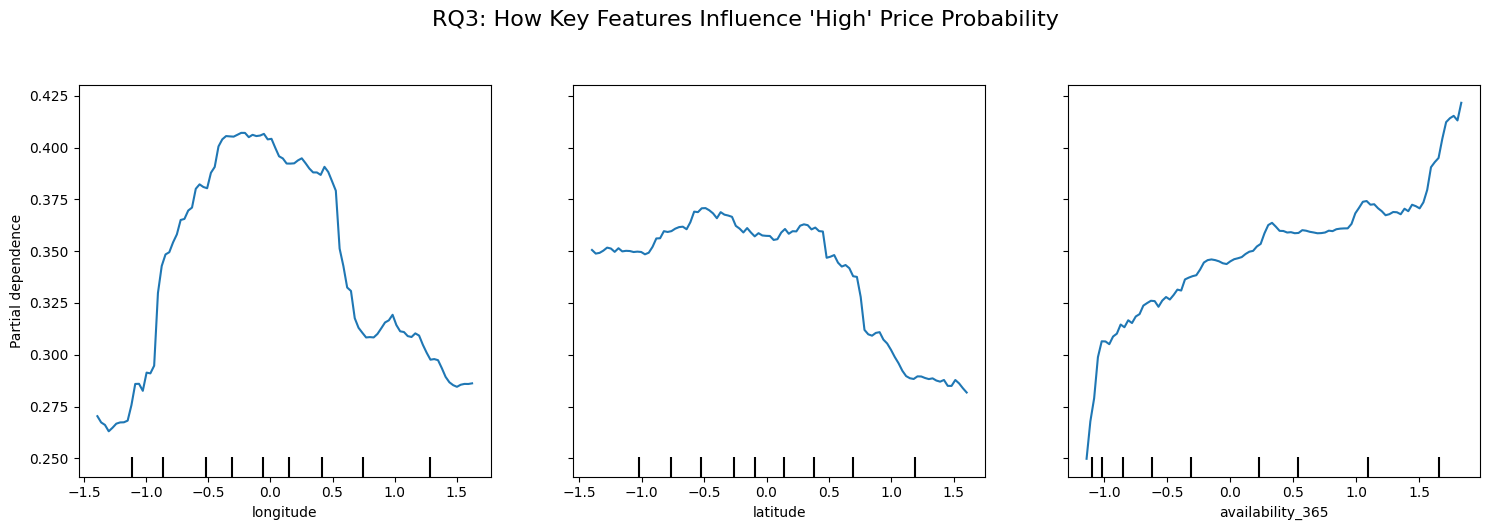

RQ3 ANALYSIS: HOW TO READ THESE GRAPHS

X-axis: The value of the feature (standardized scale).
Y-axis: Probability of listing being in 'High' price band.

RISING LINE:
  → Increasing this feature is associated with higher prices.

FALLING LINE:
  → Increasing this feature is associated with lower prices.

FLAT LINE:
  → This feature has little effect on price band classification.


In [ ]:
# Get indices of top 3 most important features
rf_model = tuned_models["Random Forest"]
top_indices = rf_model.feature_importances_.argsort()[::-1][:3]
top_features = [X_train.columns[i] for i in top_indices]

print("Generating Partial Dependence Plots...")
print(f"Top 3 features: {top_features}")
print()

# Use the target class with highest importance (usually 'High' price band)
# We'll use 'High' as the target class
target_class_name = "High"

# Generate PDP
fig, ax = plt.subplots(figsize=(15, 5))
display = PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    top_features,
    target=target_class_name,
    kind="average",
    ax=ax,
    random_state=42
)

plt.suptitle(
    f"RQ3: How Key Features Influence '{target_class_name}' Price Probability",
    y=1.05,
    fontsize=16
)
plt.tight_layout()
plt.show()

# Interpretation guide
print("=" * 70)
print("RQ3 ANALYSIS: HOW TO READ THESE GRAPHS")
print("=" * 70)
print()
print("X-axis: The value of the feature (standardized scale).")
print(f"Y-axis: Probability of listing being in '{target_class_name}' price band.")
print()
print("RISING LINE:")
print("  → Increasing this feature is associated with higher prices.")
print()
print("FALLING LINE:")
print("  → Increasing this feature is associated with lower prices.")
print()
print("FLAT LINE:")
print("  → This feature has little effect on price band classification.")
